In [1]:
import pandas as pd
import re
import string

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score

In [2]:
from google.colab import files
files.upload()
df = pd.read_csv("cleaned_dataset_final.csv")

Saving cleaned_dataset_final.csv to cleaned_dataset_final.csv


In [8]:

df = df.dropna().reset_index(drop=True)
df.isnull().values.any()

np.False_

In [9]:
X_text = df["text"].values
y = df["label"].values

In [10]:
# split data 80 for training 20 for testing and validation
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,      # keep label balance
)

# 10-10 for testing and validation
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.5,   # half of 30% → 15%
    random_state=42,
    stratify=y_temp,
)

print("Train size:", len(X_train_text))
print("Val size:  ", len(X_val_text))
print("Test size: ", len(X_test_text))


Train size: 32690
Val size:   4086
Test size:  4087


In [11]:

#  TF-IDF vectorization for numeric data
tfidf = TfidfVectorizer(
    max_features=12000,
    ngram_range=(1, 3),
    min_df=5,
    max_df=0.9
)

X_train = tfidf.fit_transform(X_train_text)
X_val   = tfidf.transform(X_val_text)
X_test  = tfidf.transform(X_test_text)

In [12]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Hate speech (label = 1)
hate_text = " ".join(X_train_text[y_train == 1])

# Non-hate speech (label = 0)
non_hate_text = " ".join(X_train_text[y_train == 0])

hate_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200,
    collocations=False
).generate(hate_text)

non_hate_wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=200,
    collocations=False
).generate(non_hate_text)



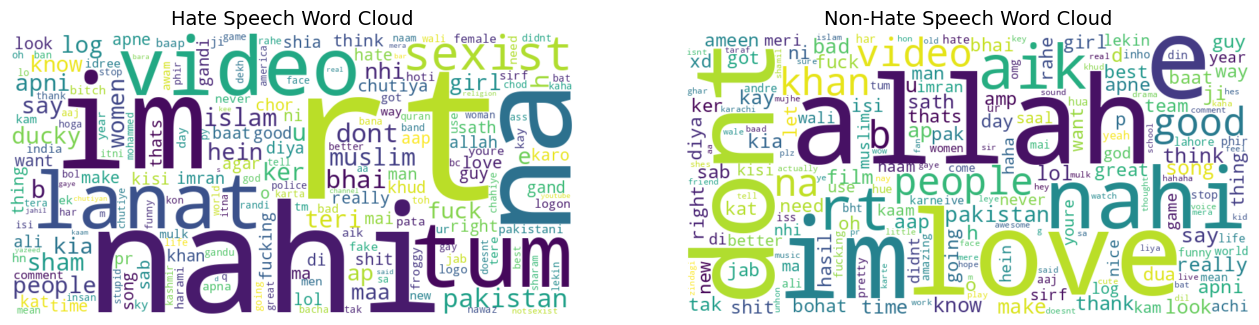

In [13]:
plt.figure(figsize=(16, 6))

plt.subplot(1, 2, 1)
plt.imshow(hate_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Hate Speech Word Cloud", fontsize=14)

plt.subplot(1, 2, 2)
plt.imshow(non_hate_wc, interpolation='bilinear')
plt.axis('off')
plt.title("Non-Hate Speech Word Cloud", fontsize=14)

plt.show()


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
models = {
    "SVM": LinearSVC(C=0.1),

    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        n_jobs=-1
    ),

    "Naive Bayes": MultinomialNB(),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        n_jobs=-1,
        random_state=42
    ),}

In [15]:
from termcolor import colored
from sklearn.metrics import accuracy_score, classification_report

results = {}

print(colored("        MODEL TRAINING & VALIDATION", "cyan", attrs=["bold"]))


for name, model in models.items():
    print(colored(f"\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━", "blue"))
    print(colored(f"TRAINING MODEL: {name}", "blue", attrs=["bold"]))
    print(colored("━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━\n", "blue"))

    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)

    acc = accuracy_score(y_val, y_pred)
    results[name] = acc

    print(colored(f" Validation Accuracy: {acc:.4f}\n", "green", attrs=["bold"]))

    print(colored(" Classification Report:", "black", attrs=["bold"]))
    print(classification_report(y_val, y_pred, digits=4))



        MODEL TRAINING & VALIDATION

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRAINING MODEL: SVM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Validation Accuracy: 0.8231

 Classification Report:
              precision    recall  f1-score   support

         0.0     0.7989    0.8627    0.8296      2040
         1.0     0.8513    0.7835    0.8160      2046

    accuracy                         0.8231      4086
   macro avg     0.8251    0.8231    0.8228      4086
weighted avg     0.8251    0.8231    0.8228      4086


━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TRAINING MODEL: Logistic Regression
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

 Validation Accuracy: 0.8228

 Classification Report:
              precision    recall  f1-score   support

         0.0     0.8010    0.8583    0.8287      2040
         1.0     0.8479    0.7874    0.8165      2046

    accuracy                         0.8228      4086
   macro avg     0.8245    0.8229    0.8226      4086
weighted avg     

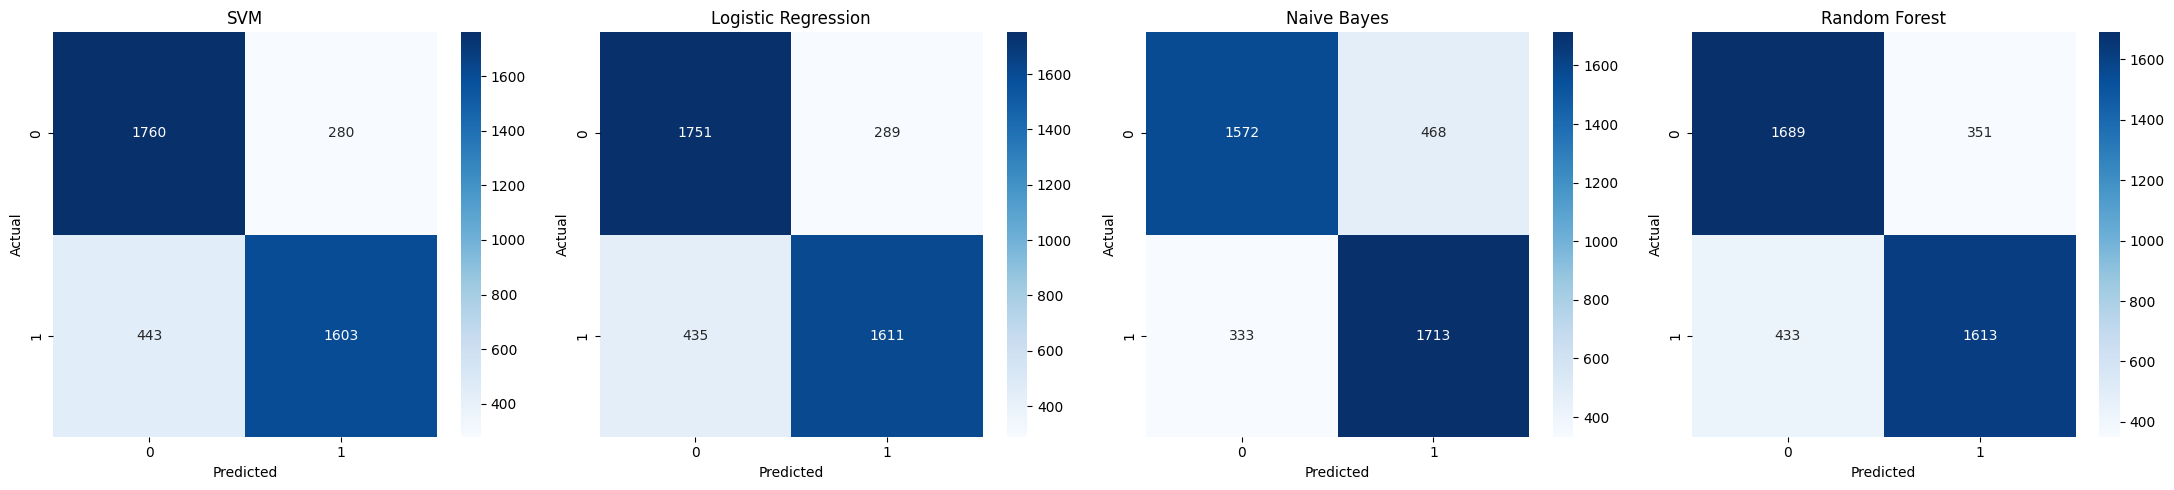

In [16]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# List of model names to maintain order
model_names = list(models.keys())

# Create a 1-row subplot with 4 columns
plt.figure(figsize=(22, 5))   # wide figure for 4 plots

for i, name in enumerate(model_names):
    model = models[name]
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)

    # subplot: 1 row, 4 columns, current index = i+1
    plt.subplot(1, len(model_names), i+1)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["0", "1"],
        yticklabels=["0", "1"]
    )
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()


In [17]:

print(colored("           VALIDATION ACCURACY SUMMARY", "cyan", attrs=["bold"]))

print(colored(f"{'MODEL':25} ACCURACY", "black", attrs=["bold"]))
print(colored("--------------------------------------------------", "white"))

for model, acc in results.items():
    print(colored(f"{model:25} {acc:.4f}", "light_blue"))

print(colored("--------------------------------------------------\n", "white"))


           VALIDATION ACCURACY SUMMARY
MODEL                     ACCURACY
--------------------------------------------------
SVM                       0.8231
Logistic Regression       0.8228
Naive Bayes               0.8040
Random Forest             0.8081
--------------------------------------------------



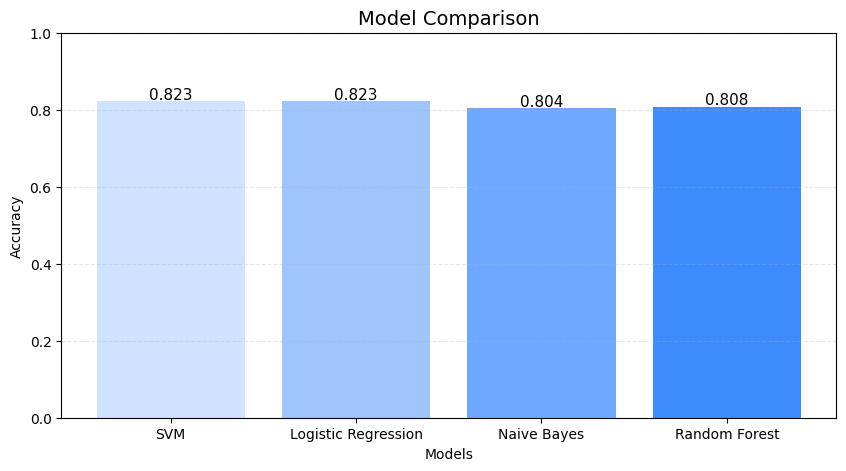

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# Blue gradient colors
colors = [
    "#cfe2ff",   # light blue
    "#9ec5fe",
    "#6ea8fe",
    "#3d8bfd"    # darker blue
]

model_names = list(results.keys())
accuracies = list(results.values())

plt.figure(figsize=(10,5))

bars = plt.bar(model_names, accuracies, color=colors)

# Add accuracy values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.005,
        f"{height:.3f}",
        ha="center",
        fontsize=11
    )

plt.ylim(0, 1)
plt.title("Model Comparison", fontsize=14)
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()


In [19]:
results = {
    "SVM": {
        "accuracy": 0.8231,
        "precision": 0.8251,
        "recall": 0.8231,
        "f1": 0.8228
    },
    "Logistic Regression": {
        "accuracy": 0.8228,
        "precision": 0.8245,
        "recall": 0.8229,
        "f1": 0.8226
    },
    "Naive Bayes": {
        "accuracy": 0.8040,
        "precision": 0.8053,
        "recall": 0.8039,
        "f1": 0.8037
    },
    "Random Forest": {
        "accuracy": 0.8081,
        "precision": 0.8086,
        "recall": 0.8082,
        "f1": 0.8081
    }
}


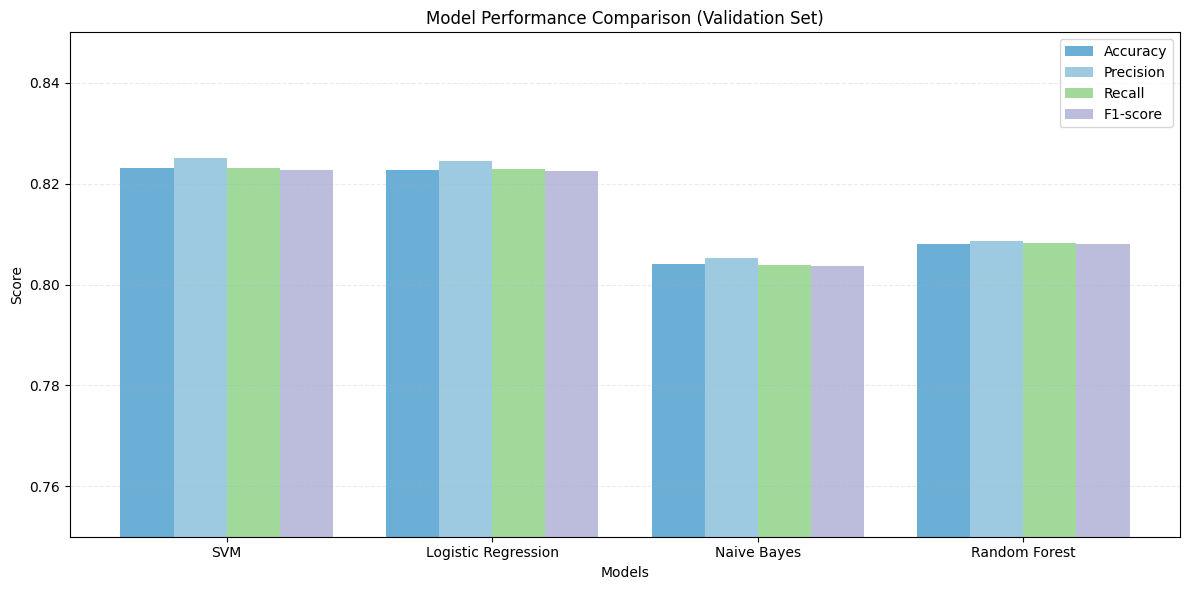

In [21]:
model_names = list(results.keys())

accuracy  = [results[m]['accuracy'] for m in model_names]
precision = [results[m]['precision'] for m in model_names]
recall    = [results[m]['recall'] for m in model_names]
f1_score  = [results[m]['f1'] for m in model_names]

x = np.arange(len(model_names))
width = 0.2

# Subtle academic color palette
colors = {
    "accuracy":  "#6baed6",   # muted blue
    "precision": "#9ecae1",   # soft teal-blue
    "recall":    "#a1d99b",   # calm green
    "f1":        "#bcbddc"    # gentle purple
}

plt.figure(figsize=(12,6))

plt.bar(x - 1.5*width, accuracy,  width, label='Accuracy',  color=colors["accuracy"])
plt.bar(x - 0.5*width, precision, width, label='Precision', color=colors["precision"])
plt.bar(x + 0.5*width, recall,    width, label='Recall',    color=colors["recall"])
plt.bar(x + 1.5*width, f1_score,  width, label='F1-score',  color=colors["f1"])

plt.xlabel("Models")
plt.ylabel("Score")
plt.title("Model Performance Comparison (Validation Set)")
plt.xticks(x, model_names)
plt.ylim(0.75, 0.85)
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

In [22]:
def predict_text(text):
    # Convert input into list because TF-IDF expects iterable
    text_vector = tfidf.transform([text])

    # Predict
    pred = models['SVM'].predict(text_vector)[0]  # or logreg_model / nb_model / pa_model

    label = "Abusive" if pred == 1 else "Not Abusive"
    return label


In [23]:
print(predict_text("hate u"))
print(predict_text("I hope you have a great day!"))
print(predict_text("khottay ka bacha tu pagal"))
print(predict_text("a gya sakoon ab nikal!"))

Abusive
Not Abusive
Abusive
Abusive


In [24]:
import numpy as np

# Map numeric labels to text
label_map = {
    0: "Non-Abusive",
    1: "Abusive"
}

def predict_text1(text, model, vectorizer=tfidf):
    """
    Take raw user text, transform with TF-IDF,
    and return predicted label (+ probability if available).
    """
    # Transform text to TF-IDF features
    X = vectorizer.transform([text])

    # Predict label
    pred_label = model.predict(X)[0]

    # Try to get probability if model supports predict_proba
    prob = None
    if hasattr(model, "predict_proba"):
        proba = model.predict_proba(X)[0]
        prob = float(np.max(proba))  # highest class probability

    return pred_label, label_map.get(pred_label, str(pred_label)), prob


In [17]:
# Example: use SVM from your models dict
best_model = models["Logistic Regression"]   # or "Logistic Regression", etc.

In [25]:
def predict_text_dynamic():
    while True:
        text = input("Enter text to classify (or type 'exit' to stop): ")

        if text.lower() == "exit":
            print("Exiting...")
            break

        # TF-IDF transform
        text_vector = tfidf.transform([text])

        # Predict using your chosen model
        pred = models['Logistic Regression'].predict(text_vector)[0]

        label = "Abusive" if pred == 1 else "Not Abusive"
        print(f"Prediction: {label}\n")
predict_text_dynamic()

Enter text to classify (or type 'exit' to stop): i hate u
Prediction: Abusive

Enter text to classify (or type 'exit' to stop): apki tasvver bohat ghatiya bohat burray lag rhy ho
Prediction: Not Abusive

Enter text to classify (or type 'exit' to stop): you look so much ugly get lost
Prediction: Not Abusive

Enter text to classify (or type 'exit' to stop): nikal jao yahann sy badtameez insaan
Prediction: Abusive

Enter text to classify (or type 'exit' to stop): Tumhari soch bohot ghatiya hai
Prediction: Abusive

Enter text to classify (or type 'exit' to stop): Aise logon ki wajah se social media kharab ho gaya hai.
Prediction: Not Abusive

Enter text to classify (or type 'exit' to stop): quit
Prediction: Not Abusive

Enter text to classify (or type 'exit' to stop): exit
Exiting...
